In [1]:
import warnings

import geopandas
import matplotlib.pyplot as plt
import numpy
from libpysal import weights

from esda import topo

In [2]:
natearth = geopandas.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)

In [3]:
natearth.sort_values("POP_EST", ascending=False).head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
139,Admin-0 country,1,2,China,CH1,1,2,Country,1,China,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((109.47521 18.1977, 108.65521 1..."
98,Admin-0 country,1,2,India,IND,0,2,Sovereign country,1,India,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((97.32711 28.26158, 97.40256 27.88254..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
8,Admin-0 country,1,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((141.00021 -2.60015, 141.01706 ..."
102,Admin-0 country,1,2,Pakistan,PAK,0,2,Sovereign country,1,Pakistan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.83745 35.49401, 76.87172 34.65354..."


<Axes: >

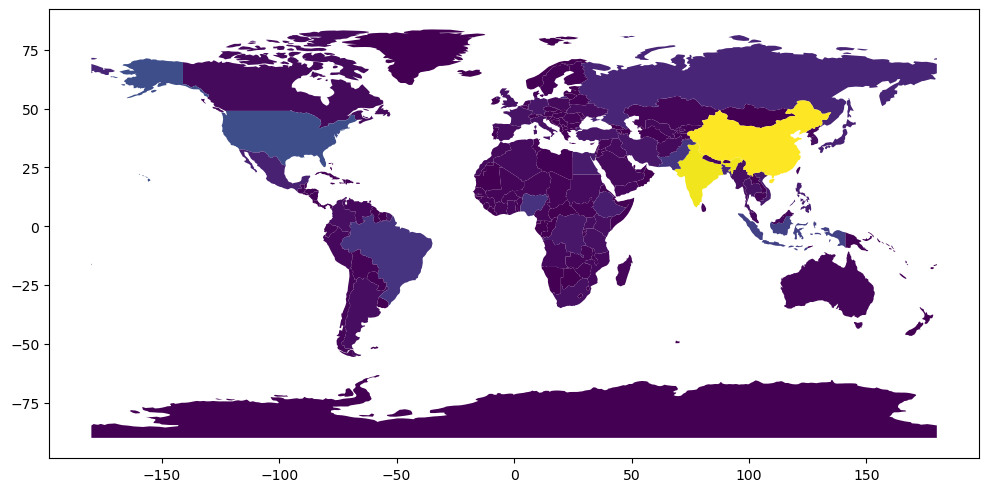

In [4]:
f, ax = plt.subplots(1, 1, figsize=(12, 6))
natearth.plot("POP_EST", ax=ax)

In [5]:
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        category=UserWarning,
        message="Geometry is in a geographic CRS",
    )

    coordinates = numpy.column_stack((natearth.centroid.x, natearth.centroid.y))

In [6]:
iso = topo.isolation(natearth["POP_EST"], coordinates, return_all=True)

In [7]:
natearth = natearth.merge(iso, left_index=True, right_index=True)

In [8]:
natearth[
    ["CONTINENT", "NAME", "rank", "POP_EST", "parent_rank", "isolation", "gap"]
].sort_values("POP_EST", ascending=False).head()

,CONTINENT,NAME,rank,POP_EST,parent_rank,isolation,gap
139,Asia,China,0.0,1.397715e+09,NaN,NaN,NaN
98,Asia,India,1.0,1.366418e+09,0.0,27.852795,3.129725e+07
4,North America,United States of America,2.0,3.282395e+08,1.0,193.538522,1.038178e+09
8,Asia,Indonesia,3.0,2.706256e+08,0.0,41.072699,1.127089e+09
102,Asia,Pakistan,4.0,2.165653e+08,1.0,12.381725,1.149852e+09


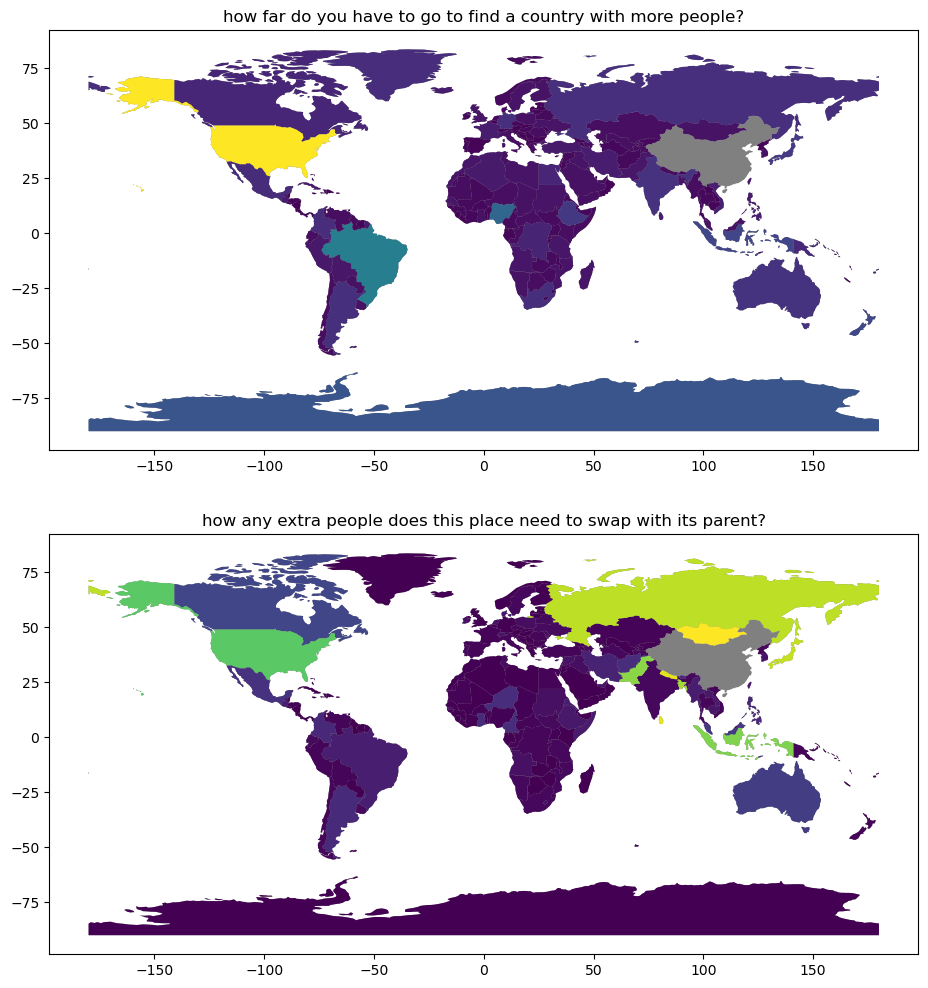

In [9]:
f, ax = plt.subplots(2, 1, figsize=(12, 12))
for i in range(2):
    natearth.plot(color="grey", ax=ax[i])
natearth.plot("isolation", ax=ax[0])
natearth.plot("gap", ax=ax[1])
ax[0].set_title("how far do you have to go to find a country with more people?")
ax[1].set_title("how any extra people does this place need to swap with its parent?")
plt.show()

In [10]:
w_rook = weights.Rook.from_dataframe(natearth, use_index=False, silence_warnings=True)
prominence = topo.prominence(natearth["POP_EST"], w_rook, return_all=True)

In [11]:
natearth = natearth.merge(
    prominence, left_index=True, right_index=True, suffixes=("", "_prom")
)

In [12]:
natearth[
    [
        "CONTINENT",
        "NAME",
        "POP_EST",
        "rank",
        "parent_rank",
        "isolation",
        "dominating_peak",
        "keycol",
        "prominence",
    ]
].sort_values("POP_EST", ascending=False).head(20)

,CONTINENT,NAME,POP_EST,rank,parent_rank,isolation,dominating_peak,keycol,prominence
139,Asia,China,1.397715e+09,0.0,NaN,NaN,139.0,107.0,1.314801e+09
98,Asia,India,1.366418e+09,1.0,0.0,27.852795,139.0,-1.0,NaN
4,North America,United States of America,3.282395e+08,2.0,1.0,193.538522,139.0,33.0,3.239931e+08
8,Asia,Indonesia,2.706256e+08,3.0,0.0,41.072699,4.0,148.0,2.386758e+08
102,Asia,Pakistan,2.165653e+08,4.0,1.0,12.381725,139.0,-1.0,NaN
29,South America,Brazil,2.110495e+08,5.0,2.0,82.093057,8.0,43.0,1.439896e+08
56,Africa,Nigeria,2.009636e+08,6.0,5.0,64.353456,29.0,55.0,1.776529e+08
99,Asia,Bangladesh,1.630462e+08,7.0,1.0,10.713323,139.0,-1.0,NaN
18,Europe,Russia,1.443735e+08,8.0,0.0,26.374718,139.0,-1.0,NaN
27,North America,Mexico,1.275755e+08,9.0,2.0,23.966775,4.0,-1.0,NaN


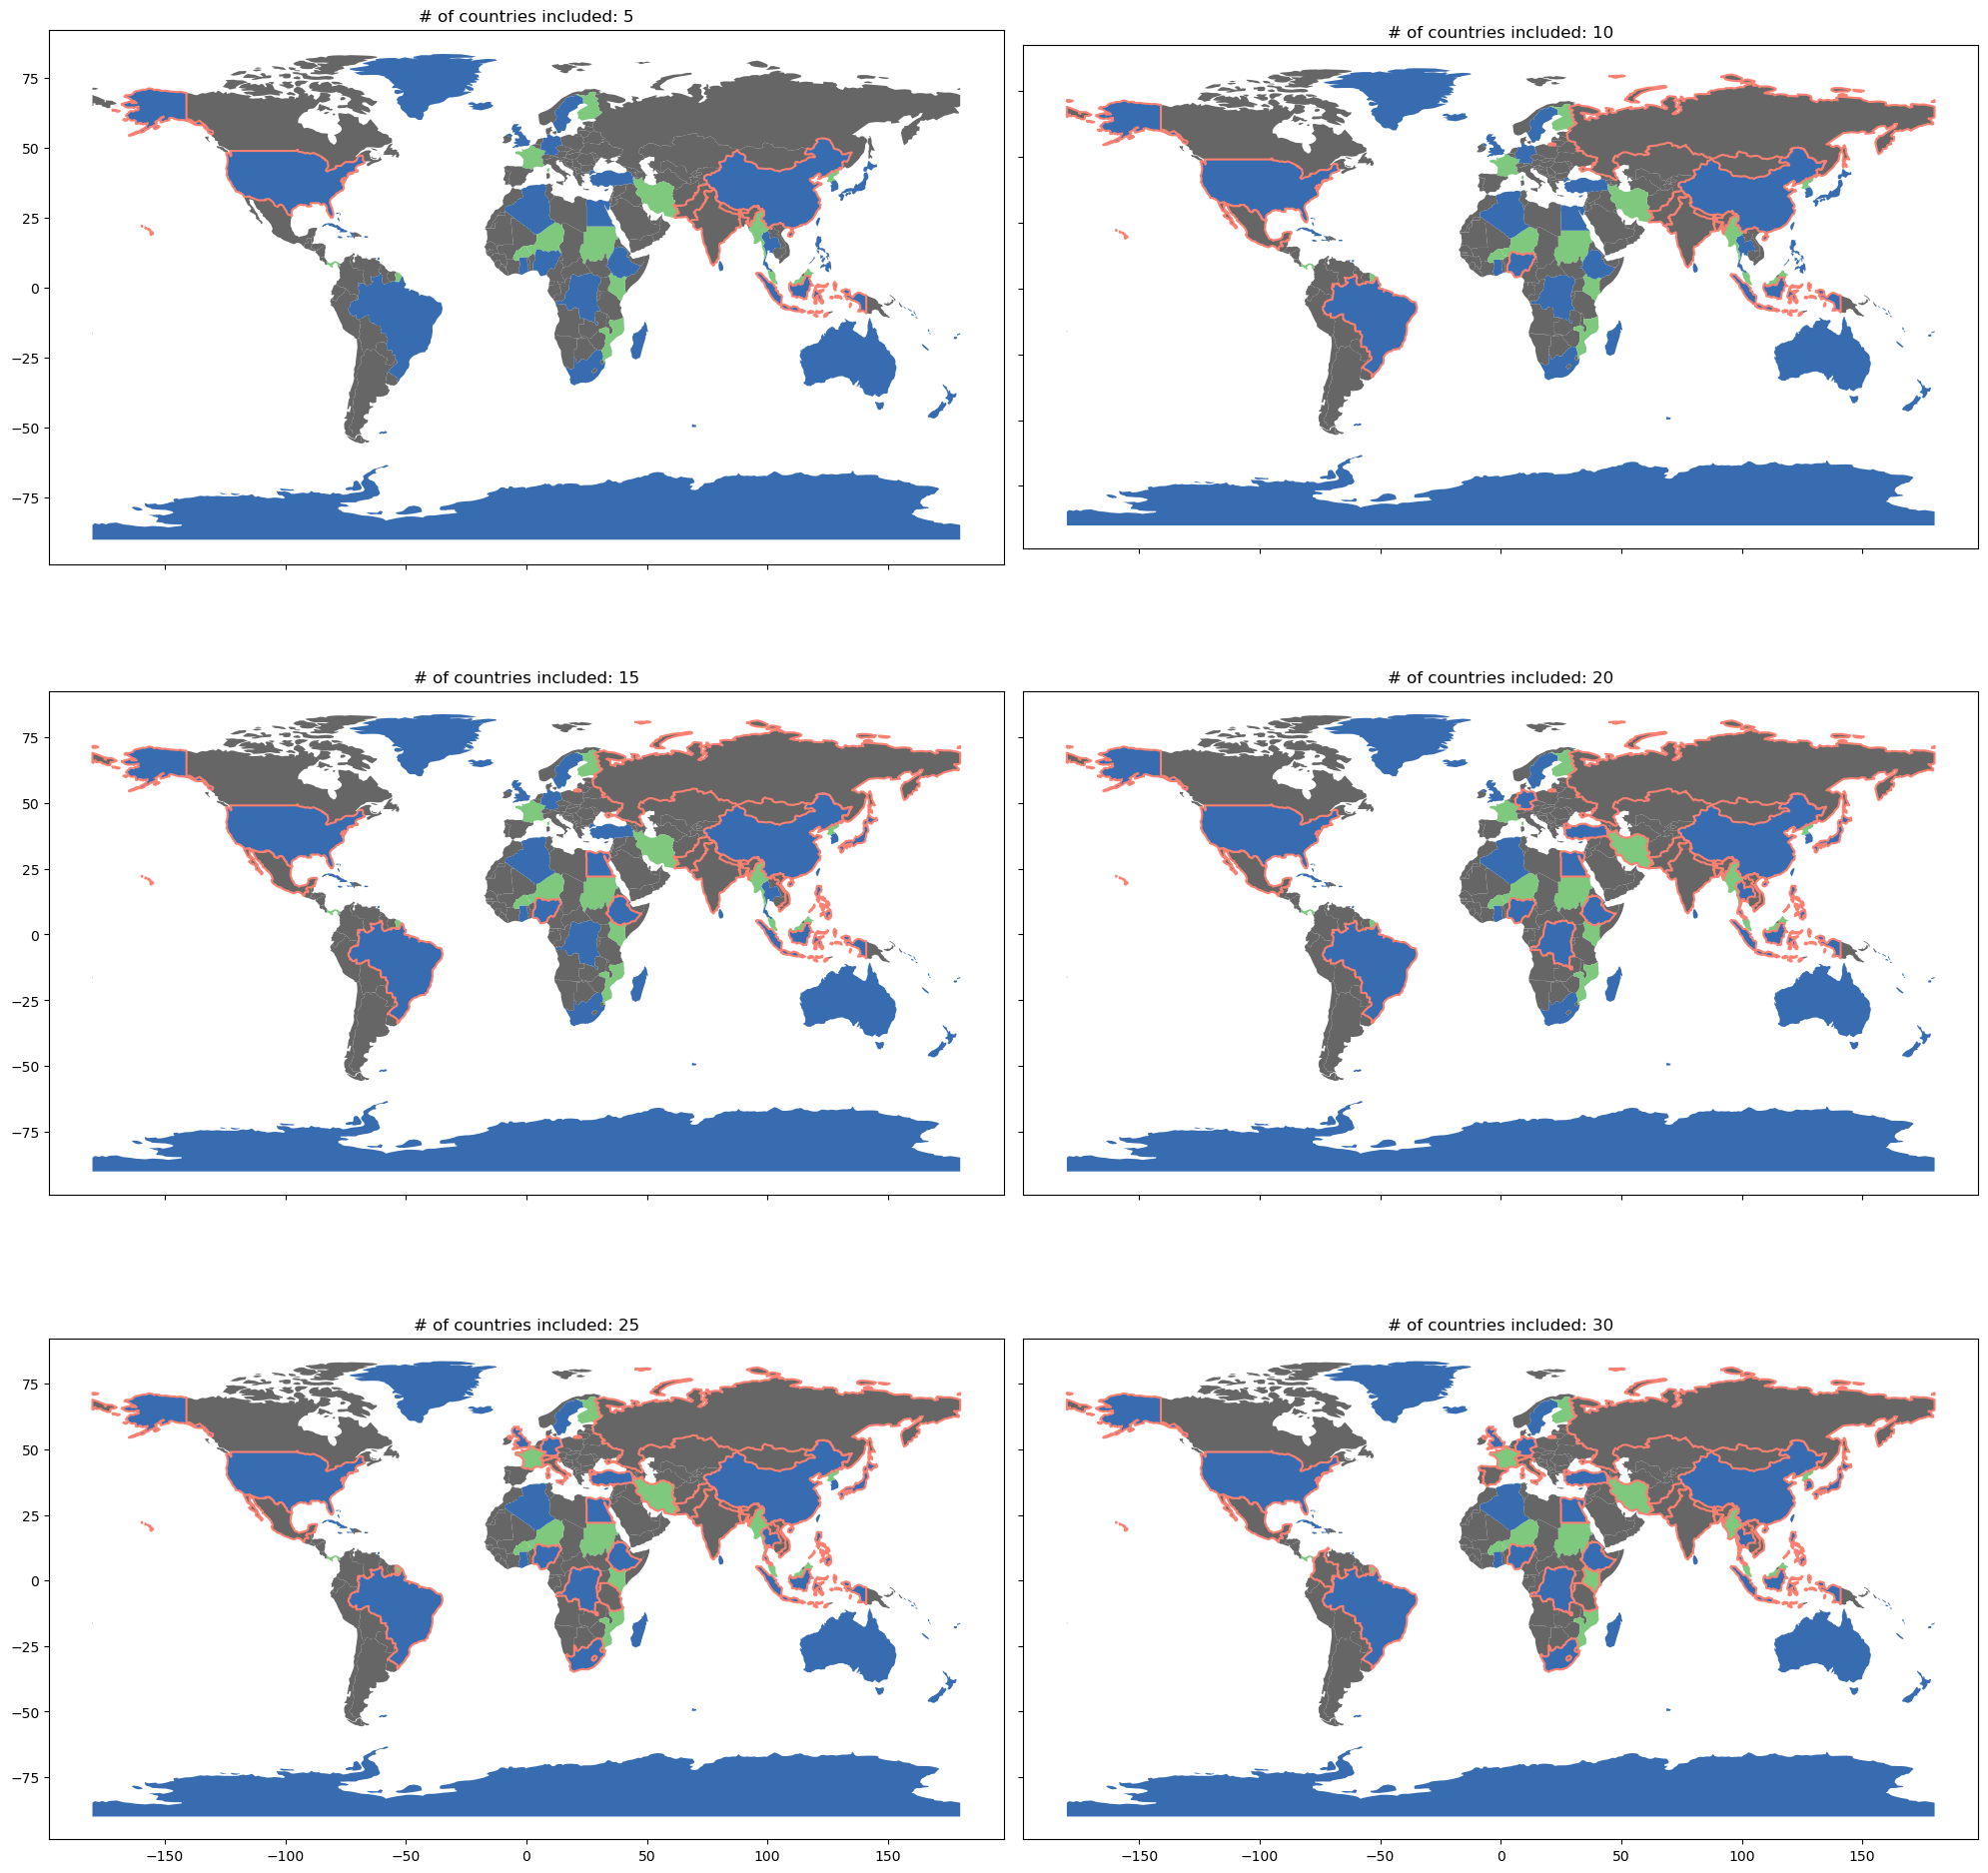

In [13]:
f, ax = plt.subplots(3, 2, figsize=(20, 20), sharex=True, sharey=True)
ax = ax.flatten()
for ix, rank in enumerate(range(5, 31, 5)):
    natearth.plot("classification", ax=ax[ix], cmap="Accent")
    natearth.sort_values("POP_EST", ascending=False).iloc[0:rank].boundary.plot(
        color="salmon", ax=ax[ix]
    )
    ax[ix].set_title(f"# of countries included: {rank}")
f.tight_layout()
plt.show()

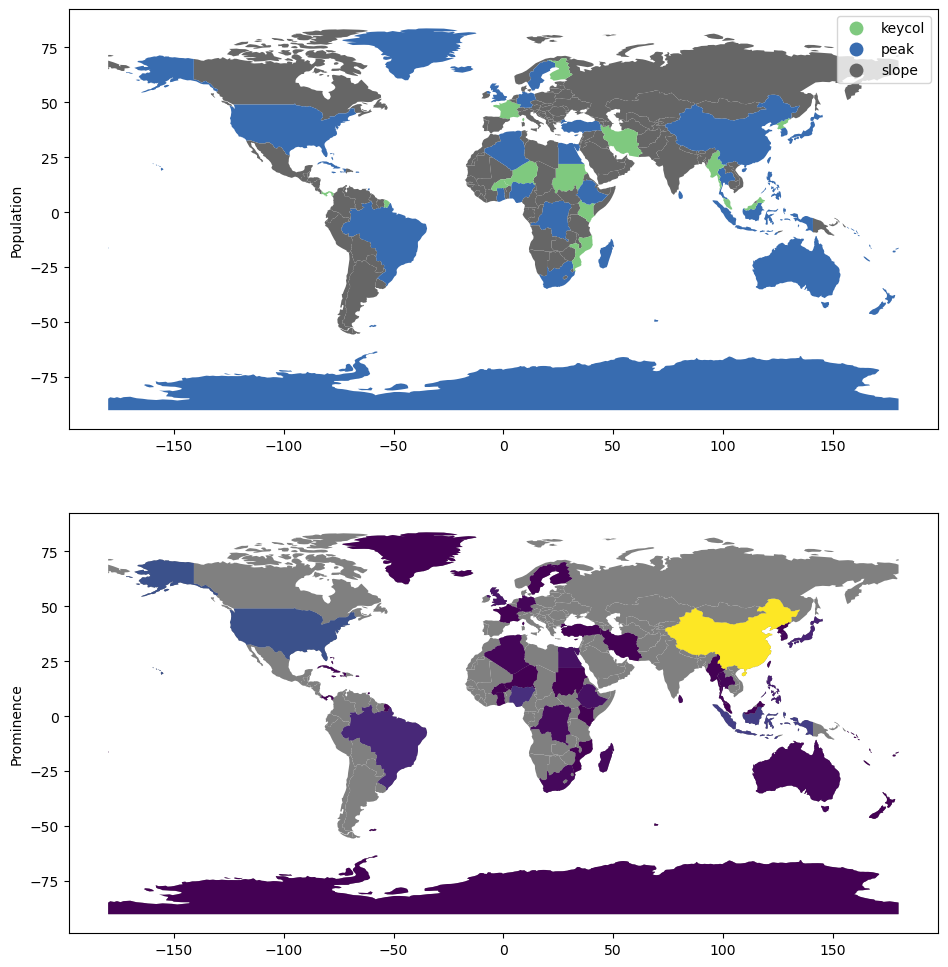

In [14]:
f, ax = plt.subplots(2, 1, figsize=(12, 12))
natearth.plot("classification", ax=ax[0], legend=True, cmap="Accent")
natearth.plot(color="grey", ax=ax[1])
natearth.plot("prominence", ax=ax[1])
ax[0].set_ylabel("Population")
ax[1].set_ylabel("Prominence")
plt.show()